# Topic Modeling: Latent Dirichlet Allocation vs. BERTopic

Paste in image. Hit F2 in the name in markdown to rename.

pip install pandas
pip install numpy
pip install matplotlib
pip install plotly
pip install seaborn

In [1]:
import json
import pandas as pd
import numpy as np
import random
import re

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv('reviews_data.csv')
print('Starbucks Reviews Dataset Size:', data.shape)
data.head()

Starbucks Reviews Dataset Size: (850, 6)


,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


In [3]:
pd.set_option('display.max_colwidth', None)
data['Review'].sample(10)

457                                                                                                                                                                                              My 16-year-old daughter went into the Starbucks inside the Kroger, Jefferson, GA. She was second in line, ordered and paid for her drink. Several people came in after her, ordered their drinks and left before she received her drink. After I dropped her off at school, I contacted this Starbucks to find out what happened. The lady I spoke with seemed uncaring and unconcerned about the situation. She stated that the cups may have gotten out of order, she wasn't making the drinks and she did not know. Not once in the conversation did she apologize or sound as if she cared. 
231    DO NOT drink at STARBUCKS St. Leonards, Ringwood, I was fined £100 for parking there for 105 mins because they were slow serving drinks and lunch. My friend and I met there for coffee and lunch, as we often used to do, BUT 

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


In [5]:
# Let's see if any of the reviews are redundant.
data.groupby(['Review'])['Review'].agg(['count']).sort_values(by='count', ascending=False)

,count
Review,
No Review Text,37
I then decided to call and ask her for her manager's #. She hung up on me 6 times after that and would not give me any #'s or names of her superior. The last time she answered and stated that I was getting the employee I asked to speak with in trouble. I am a regular at starbucks but after this crap I will go It's A Grind. I purchase coffe drinks 5-7 times a week too!,1
"ONLINE STORE IS USELESS. You can only call Mon.-Fri. 8 a.m.-5 p.m -- terrible customer service. Takes 10 days before they ship the order. Now they are using lowest level of delivery, takes 7-10 days to arrive. They are continually out of stock on items. Emails are not answered promptly. When they do answer they tell you it will ship and then it doesn't.",1
"My sweetheart and I went into our neighborhood Starbucks to get a coffee. We were standing waiting to be served looked at the food on display and noticed there was flies landing on the food and flying around. We pulled an employee aside and gestured towards the food and he said, ""Yes we are aware and it’s just a display we are not serving any of that to the public."" We were satisfied with that response and not more than 30 seconds go by and we witness a barista taking food out of the fly infested case put in oven to warm up for the public.",1
"My wife and I were at the Starbucks location at Bay St. and Cumberland here in Toronto. We are loyal customers, but this particular day, Saturday, April 14, 20012, was not very pleasant. I was pick-pocketed. My wallet was gone. I know it’s not your fault, but it’s easy target where your seats are at one point being very narrow. Hoards of people collect at one time and that’s where it happened. We truly enjoy your espressos and cappuccinos. Unfortunately, because of this incident, we will not be returning to this location and we will be informing our friends to be vigilant when going there. This was very unfortunate.",1
...,...
"I like the rewards program and the variety of drinks and specials. They have a good attitude, always ready to serve and make the drink the way you want it.",1
I like the way the set up is in the store and also the ambiance. The staff are nice and courteous. I like the different drinks and food items that are healthy choices.,1
"I like your product, particularly your coffee but notice that your cups, more often than not, tend to leak at the seam when the lid is in place. I have plenty of ruined shirts and a big dry cleaning bill to prove it.",1


In [7]:
data = data[ data.Review != 'No Review Text' ].copy()
print('Starbucks Reviews w/Text Dataset Size:', data.shape)

Starbucks Reviews w/Text Dataset Size: (813, 6)


In [8]:
data.describe()

,Rating
count,703.000000
mean,1.871977
std,1.399266
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000


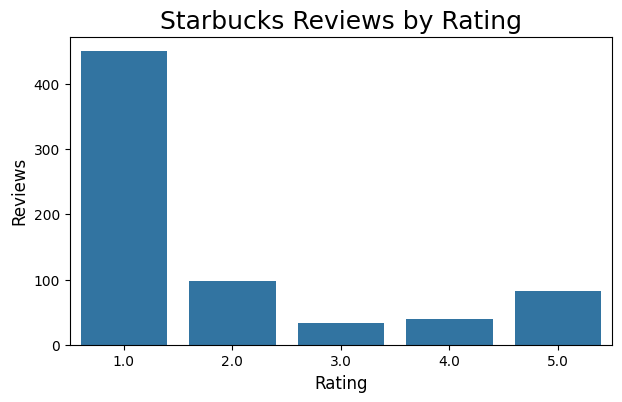

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='Rating')
plt.title('Starbucks Reviews by Rating', fontsize=18)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Reviews', fontsize=12)
plt.show()

In [10]:
# Because reviews are so heavily negative, let's model 1-2 star reviews and see what's up.
df = data[ data.Rating <= 2 ].copy()
print('Starbucks Negative Reviews Dataset Size:', df.shape)

Starbucks Negative Reviews Dataset Size: (548, 6)


pip install nltk
pip install bertopic
pip install gensim
pip install spacy
python -m spacy download en_core_web_sm
pip install pyldavis

In [11]:
import nltk
# nltk.download()    # you only have to download this the first time
from nltk.corpus import stopwords
from gensim.parsing.preprocessing import STOPWORDS as gensimSTOPWORDS
import spacy

In [ ]:
stop_words = set(stopwords.words('english'))
stop_words.update(gensimSTOPWORDS)
stop_words.update(['starbuck','starbucks','coffee','drink'])
stop_words = list(stop_words)

In [ ]:
nlp = spacy.load('en_core_web_md', disable=['parser', 'ner'])

In [ ]:
# Tokens: There are a lot of great tokenizers out there, but here we make a simple one
docs = df.Review.to_list()
tokens = []

for doc in docs:
    doc = str(doc).lower()
    chars = "`*{}[]()<>#+=;,.:!$?"
    for c in chars:
        if c in doc:
            doc = doc.replace(c, ' ')
    doc = re.sub('\"','',doc)  # remove double quotes
    doc = re.sub('-','_',doc)  # remove hypens
    doc = doc.replace('/n',' ')  # remove carriage returns
    doc = re.sub('\s+',' ',doc)  # remove extra spaces
    
    # LDA performs much better with lemmitization
    doc = [ word for word in nlp(doc) if len(word) > 1 ]
    doc = [ token.lemma_ for token in doc ]
    doc = [ word.lower() for word in doc if word.lower() not in stop_words and word.isalpha() ]
    tokens.append(doc)

df['doc'] = docs
df['tokens'] = tokens
df['token_count'] = [ len(doc) for doc in tokens ]

In [ ]:
df.head(5)

In [ ]:
i = random.randint(0,len(docs))
print(docs[i])
print(tokens[i])

In [ ]:
fig = plt.figure(figsize=(7,4))
sns.histplot(x='token_count', data=df, bins=25)
plt.title('Starbucks Negative Reviews Word Counts', fontsize=16)
plt.xlabel('Word Count per Review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(7,4))
sns.boxplot(x='token_count', data=df)
plt.title('Starbucks Negative Reviews Word Counts', fontsize=16)
plt.xlabel('Word Count per Review')
plt.tight_layout()
plt.show()

## BERTopic

### Tuning

For this turning part, I'm not sure if it is appropriate to share this in the article since this is kind of copying someone else's work. Prob just going to tune for myself and show finished model.

In [ ]:
import umap
import hdbscan
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

In [ ]:
model_name = 'bertopic'
docs = df.doc.to_list()
reviews = df.Review.apply(lambda x: str(x)[:min(len(x),150)])

In [ ]:
# create embeddings
n = len(docs)
batch_size = 10

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = np.zeros((n, embedding_model.get_sentence_embedding_dimension()))

for i in tqdm(range(0, n, batch_size)):
    i_end = min(i+batch_size, n)
    batch = docs[i:i_end]
    batch_embed = embedding_model.encode(batch, normalize_embeddings=True)
    embeddings[i:i_end,:] = batch_embed

In [ ]:
# 3D Scatterplot
if 1 == 0:
    n_components = 100
    nns = [  2, 5, 10, 15, 20 ]
    mds = [ 0.1, 0.25, 0.5, 0.75, 0.99 ]
    metrics = [ 'euclidean', 'cosine' ]

    # nns = [ 4 ]
    # mds = [ 0.5 ]
    # metrics = [ 'cosine' ]

    for n_neighbors in nns:
        for min_dist in mds:
            for metric in metrics:
                umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=38)
                reduced_embeddings = umap_model.fit_transform(embeddings)

                fig = px.scatter_3d(
                    x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], z=reduced_embeddings[:,2],
                    custom_data=[reviews],
                )
                fig.update_traces(
                    hovertemplate="<br>".join([
                        "Review: %{customdata[0]}",
                    ])
                )

                fig.write_html(f'{model_name}/tuning_graphs/umap-topics-3d-parameter-tuning-{metric}-{n_neighbors}-{min_dist}.html', include_plotlyjs="cdn", full_html=False)

In [ ]:
n_components = 50
n_neighbors = 10
min_dist = 0.5
metric = 'cosine'

fit = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=36)
reduced_embeddings = fit.fit_transform(embeddings)

In [ ]:
clusterer = hdbscan.HDBSCAN()
clusterer.fit(reduced_embeddings)
clusterer.get_params()

In [ ]:
# check number of outliers
print(len(set(clusterer.labels_)))
print((clusterer.labels_ == -1).sum())

In [ ]:
min_cls = [ 2, 3, 4, 5, 6, 7, 8, 9, 10]
min_smps = [None, 1, 2, 3, 4, 5]
outliers = []

for min_samples in tqdm(min_smps):
    for min_cluster_size in min_cls:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        clusterer.fit(reduced_embeddings)

        outliers.append((f'min_cluster_size={min_cluster_size}, min_samples={min_samples}', len(set(clusterer.labels_)), 
            (clusterer.labels_ == -1).sum(), (.05 * df.shape[0]), (.1 * df.shape[0]), (.2 * df.shape[0]), (.3 * df.shape[0])))

In [ ]:
outliers = sorted(outliers, key=lambda x: x[2])
hdbscan_df = pd.DataFrame(outliers, columns = ['params', 'clusters', 'outliers', 'sample_05_pct','sample_10_pct','sample_20_pct',
    'sample_30_pct'])
hdbscan_df.head(30)

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.lineplot(data=hdbscan_df)
plt.legend(loc='upper right')
plt.title('HDBScan Clusters vs. Outliers')
plt.xlabel('Parameter Setting')
plt.ylabel('Count (Clusters or Documents)')
fig.savefig(f'{model_name}/tuning_graphs/hdbscan-cluster-outliers-{n_neighbors}-{min_dist}.png')
plt.show()

In [ ]:
min_cluster_size = 10
min_samples = 1

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
clusterer.fit(reduced_embeddings)

In [ ]:
fig = plt.figure(figsize=(20,5))
sns.countplot(x=clusterer.labels_)
plt.title('HDBScan Clustering')
fig.savefig(f'{model_name}/tuning_graphs/hdbscan-cluster-counts-{n_neighbors}-{min_dist}-{min_cluster_size}-{min_samples}.png')
plt.show()

In [ ]:
clusters = [str(x) for x in clusterer.labels_]
palette = sns.color_palette("hls",len(set(clusters))).as_hex()

fig = px.scatter_3d(
    x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], z=reduced_embeddings[:,2],
    color=clusters,
    custom_data=[clusters,reviews],
    color_discrete_sequence=palette
)
fig.update_traces(
    hovertemplate="<br>".join([
        "cluster: %{customdata[0]}",
        "reivew: %{customdata[1]}"
    ])
)

fig.write_html(f'{model_name}/tuning_graphs/hdbscan-topics-3d-{n_neighbors}-{min_dist}-{min_cluster_size}-{min_samples}.html', include_plotlyjs="cdn", full_html=False)

### Model

In [ ]:
from bertopic import BERTopic
import umap
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
stop_words = set(stopwords.words('english'))
stop_words.update(gensimSTOPWORDS)
stop_words.update(['starbuck','starbucks'])
stop_words = list(stop_words)

In [ ]:
n_components = 50
n_neighbors = 10
min_dist = 0.5
metric = 'cosine'
min_cluster_size = 10
min_samples = 1

In [ ]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = umap.UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=min_dist, metric=metric, random_state=38)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, prediction_data=True, gen_min_span_tree=True)
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words=stop_words)

In [ ]:
docs = df.doc.to_list()

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    language='english',
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
topic_model.get_params()

In [ ]:
df['bertopic_topic'] = topic_model.topics_
df['bertopic_label'] = df['bertopic_topic'].apply(lambda x: topic_model.topic_labels_[x])
topic_model.save(f'{model_name}/model')

In [ ]:
fig = plt.figure(figsize=(7,10))
sns.countplot(y='bertopic_label', data=df, order=df['bertopic_label'].value_counts().index)
plt.title('Topic Sizes', fontsize=18)
plt.xticks(rotation=90)
plt.xlabel('Topic')
plt.ylabel('Count')
plt.tight_layout()
fig.savefig(f'{model_name}/bertopic-topic-sizes.png')
plt.show()

In [ ]:
rep_docs = { str(k) : v for k,v in topic_model.representative_docs_.items()}

with open(f'{model_name}/representative_documents.json', 'w') as f:
    f.write(json.dumps(rep_docs, indent=4))

In [ ]:
fig = topic_model.visualize_barchart(top_n_topics=50, n_words=8, width=300)
fig.write_html(f'{model_name}/bertopic-topic-word-scores.html')
fig.show()

In [ ]:
search_topics, search_similarity = topic_model.find_topics('manager was rude', top_n=3)
print(search_topics)
print(search_similarity)

In [ ]:
reduced_embeddings = umap_model.fit_transform(embeddings)

In [ ]:
clusters = df['bertopic_label']
palette = sns.color_palette("hls",len(set(clusters))).as_hex()
reviews = df.Review.apply(lambda x: str(x)[:min(len(x),250)])

fig = px.scatter_3d(
    x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], z=reduced_embeddings[:,2],
    color=clusters,
    custom_data=[clusters,reviews],
    color_discrete_sequence=palette
)
fig.update_traces(
    hovertemplate="<br>".join([
        "cluster: %{customdata[0]}",
        "review: %{customdata[1]}"
    ])
)

fig.write_html(f'{model_name}/bertopic-3d.html', include_plotlyjs="cdn", full_html=False)
fig.show()

In [ ]:
fig = topic_model.visualize_topics()
fig.write_html(f'{model_name}/bertopic-intertopic-distance.html')
fig.show()

In [ ]:
fig = topic_model.visualize_hierarchy(custom_labels=True)
fig.write_html(f'{model_name}/bertopic-topic-hierarchy.html')
fig.show()

In [ ]:
fig = topic_model.visualize_documents(df['tokens'].to_list(), reduced_embeddings=reduced_embeddings)
fig.write_html(f'{model_name}/bertopic-topic-documents.html')
fig.show()

In [ ]:
fig = topic_model.visualize_heatmap(custom_labels=True)
fig.write_html(f'{model_name}/bertopic-heatmap.html')
fig.show()

## LDA

In [ ]:
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from gensim.models import ldamodel
import pyLDAvis
import pyLDAvis.gensim

### Tuning

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [ ]:
texts = df.tokens.to_list()
id2word = corpora.Dictionary(texts)
corpus = [ id2word.doc2bow(doc) for doc in texts ]

In [ ]:
if 1 == 0:
    ks = [ 6, 7, 8, 9, 10, 11, 12 ]
    # alphas = ['symmetric','asymmetric',0.01,0.1,1,10,100]
    alphas = ['asymmetric']
    betas = ['symmetric',0.01,0.1,1,10,25]

    for k in ks:
        for alpha in alphas:
            for beta in betas:
                lda_model = ldamodel.LdaModel(
                                                corpus=corpus,
                                                id2word=id2word,
                                                num_topics=k, 
                                                random_state=38,
                                                #chunksize=2000,
                                                passes=10,
                                                alpha=alpha,
                                                eta=beta,
                                                per_word_topics=True
                ) 
                lda_coherence = CoherenceModel(model=lda_model, corpus=corpus, dictionary=id2word, texts=texts, coherence='c_v').get_coherence()
                lda_perplexity = lda_model.log_perplexity(corpus)
                print(f"k: {k}, alpha: {alpha}, beta: {beta}, coherence: {lda_coherence}, perplexity: {lda_perplexity}")

### Model

In [ ]:
# k: 7, alpha: asymmetric, beta: 10, coherence: 0.5184896343229826, perplexity: -7.624321892697227
# LDA Coherence: 0.48659494732959735
# LDA Perplexity: -7.684521951697413

texts = df.tokens.to_list()
id2word = corpora.Dictionary(texts)
corpus = [ id2word.doc2bow(doc) for doc in texts ]
lda_model = ldamodel.LdaModel(
                                corpus=corpus,
                                id2word=id2word,
                                num_topics=15,
                                random_state=38,
                                #chunksize=2000,
                                passes=10,
                                alpha='auto',
                                per_word_topics=True
) 

In [ ]:
lda_coherence = CoherenceModel(model=lda_model, corpus=corpus, dictionary=id2word, texts=texts, coherence='c_v').get_coherence()
lda_perplexity = lda_model.log_perplexity(corpus)

In [ ]:
print('LDA Coherence:', lda_coherence)
print('LDA Perplexity:', lda_perplexity)

In [ ]:
LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, sort_topics=False)
pyLDAvis.save_html(LDAvis_prepared, f'lda/lda_pyLDAvis_tuned.html')

In [ ]:
lda_model.print_topics(num_topics=-1)

In [ ]:
def get_lda_topics(tokens):
       corpus = id2word.doc2bow(tokens)
       topics = lda_model.get_document_topics(corpus, minimum_probability=0.1)
       topics_sorted = list(sorted(topics, key=lambda tup: tup[1], reverse=True))
       return topics_sorted

df['lda_topics'] = df.tokens.apply(lambda x: get_lda_topics(x))

In [ ]:
df[['Review','lda_topics']].head(15)